# GW Response Tutorial Notebook

In [1]:
import gw_response as gwr
import sys

print("Running on:", sys.version)

Running on: 3.13.5 (main, Aug 22 2025, 14:32:32) [GCC 15.2.1 20250813]


In [2]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import warnings

warnings.filterwarnings("ignore")

GENERATE_TEST_DATA = False

## Module: `constants`

Contains dataclasses for standard physical constants and TDI basis transformations

In [3]:
ps = gwr.PhysicalConstants()
print("Object:", ps)
print("Example (c in m/s):", ps.light_speed)

Object: PhysicalConstants(light_speed=299792458.0, hour=3600.0, day=86400.0, yr=31557600.0, sidereal_day=86164.0905, Hubble_over_h=3.24e-18, AU=149597870700.0, cmb_dipole=Array([-0.972,  0.137, -0.191], dtype=float64))
Example (c in m/s): 299792458.0


## Module `utils`

Implements a few helper functions relevant to e.g. the pixelisation of the sky and computing complex exponentials

Number of pixels: 768
theta shape: (768,)
phi shape: (768,)
angular map shape: (768, 2)


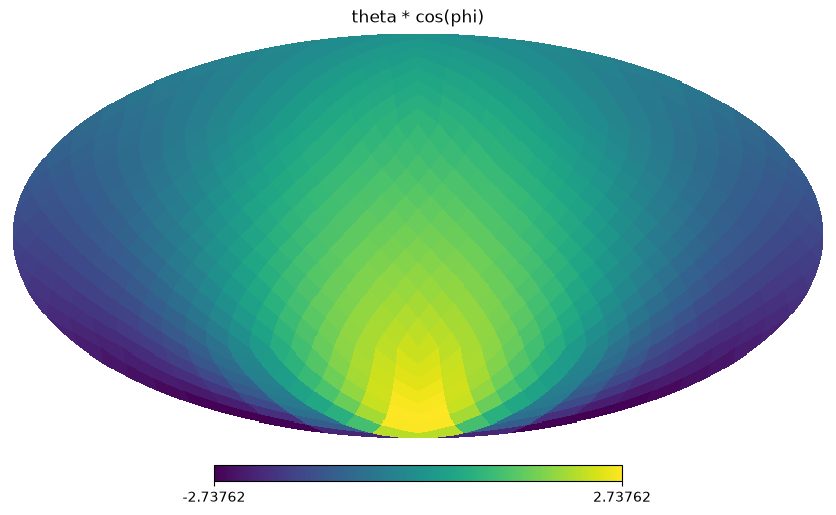

In [4]:
# Pixel class
pixel_class = gwr.Pixel(NSIDE=8)
print("Number of pixels:", pixel_class.NPIX)
print("theta shape:", pixel_class.theta_pixel.shape)
print("phi shape:", pixel_class.phi_pixel.shape)
print("angular map shape:", pixel_class.angular_map.shape)
hp.mollview(
    pixel_class.theta_pixel * jnp.cos(pixel_class.phi_pixel),
    title="theta * cos(phi)",
)

theta = pixel_class.theta_pixel
phi = pixel_class.phi_pixel

if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/pixel_theta.npy", np.array(theta))
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/pixel_phi.npy", np.array(phi))
if GENERATE_TEST_DATA:
    np.save(
        "../testing/test_data_ligo/pixel_angular_map.npy",
        np.array(pixel_class.angular_map),
    )

## Module: `ligo`

Implementation of the LIGO detector class and various helper functions for this

In [5]:
from gw_response.ground_based.ligo import _SITE_GEOMETRIES

In [6]:
LIGOHAN_ARM1   = _SITE_GEOMETRIES['Hanford']['arm1']
LIGOHAN_ARM2   = _SITE_GEOMETRIES['Hanford']['arm2']
LIGOHAN_C      = _SITE_GEOMETRIES['Hanford']['center']


# Can also be accessed with LIGO_positions
ligo_analytical_positions = gwr.LIGO_positions(
    LIGOHAN_C, LIGOHAN_ARM1, LIGOHAN_ARM2, 4.0e3, jnp.array([1.0])
)

print(
    "LIGO test mass positions shape:",
    ligo_analytical_positions.shape,
    "[time, vector, satellite]",
)

if GENERATE_TEST_DATA:
    np.save(
        "../testing/test_data_ligo/ligo_positions.npy",
        np.array(ligo_analytical_positions),
    )

LIGO test mass positions shape: (1, 3, 3) [time, vector, satellite]


In [7]:
ligo_arms_matrix = gwr.LIGO_arms_matrix(
    LIGOHAN_ARM1, LIGOHAN_ARM2, 4.0e3, jnp.array([1.0])
)

if GENERATE_TEST_DATA:
    np.save(
        "../testing/test_data_ligo/ligo_arms_matrix.npy",
        np.array(ligo_arms_matrix),
    )

ligo_arms_matrix.shape

(1, 3, 4)

In [8]:
arm_lengths = jnp.sqrt(jnp.einsum("tij,tij->tj", ligo_arms_matrix, ligo_arms_matrix))
print("Arm lengths:", arm_lengths[0, :])

if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/arm_lengths.npy", np.array(arm_lengths))

Arm lengths: [4000.         4000.00000001 4000.         4000.00000001]


In [9]:
# LIGO detector object available to access all these properties
ligo = gwr.LIGO()
print("LIGO object:", ligo)

# Generate a given frequency grid between ligo.fmin and ligo.fmax
frequencies = ligo.frequency_vec(10)
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/frequencies.npy", np.array(frequencies))
print("Frequencies:\n", frequencies)

# Compute the corresponding k vector (f * arm_length / c)
kl_vector = ligo.klvector(frequencies)
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/kl_vector.npy", np.array(kl_vector))
print("kl vector:\n", kl_vector)

# or the corresponding x vector (2 pi f L / c) for a given frequency grid
x_vector = ligo.x(frequencies)
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/x_vector.npy", np.array(x_vector))
print("x vector:\n", x_vector)

# Easily access test mass positions and detector arms matrix
vertex_positions = ligo.vertex_positions(1)
print("Vertex positions shape:", vertex_positions.shape)

arms_matrix = ligo.detector_arms(1)
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/arms_matrix.npy", np.array(arms_matrix))
print("Arms matrix shape:", arms_matrix.shape)

LIGO object: LIGO(which_detector='Hanford', name='LIGO Hanford', ps=PhysicalConstants(light_speed=299792458.0, hour=3600.0, day=86400.0, yr=31557600.0, sidereal_day=86164.0905, Hubble_over_h=3.24e-18, AU=149597870700.0, cmb_dipole=Array([-0.972,  0.137, -0.191], dtype=float64)), fmin=1.0, fmax=2000.0, armlength=4000.0, res=0.1, default_combination='Michelson', include_earth_rotation=False, long_wavelength_approximation=False, center=Array([-2155148.24112, -3823577.18398,  4617925.37775], dtype=float64), arm1=Array([-0.22389266,  0.79983063,  0.55690488], dtype=float64), arm2=Array([-0.91397819,  0.02609404, -0.40492342], dtype=float64), response=Response(ps=PhysicalConstants(light_speed=299792458.0, hour=3600.0, day=86400.0, yr=31557600.0, sidereal_day=86164.0905, Hubble_over_h=3.24e-18, AU=149597870700.0, cmb_dipole=Array([-0.972,  0.137, -0.191], dtype=float64)), waveform=None, single_link_response={}, linear_integrand={}, quadratic_integrand={}, quadratic_integrated={}), noise=Noise

Now that the detector exists we can easily change reference frame

In [10]:
sat_positions = ligo.vertex_positions(0.0)[0]
p1, p2, p3 = sat_positions[:, 0], sat_positions[:, 1], sat_positions[:, 2]

# Or shift a set of positions to the centre
sp1, sp2, sp3 = gwr.shift_to_center(p1, p2, p3)

print("New centre of mass (~[0, 0, 0]):", sp1 + sp2 + sp3)

New centre of mass (~[0, 0, 0]): [ 1.06410880e-10 -1.70985004e-10  1.70030034e-09]


In [11]:
# Define a new denser frequency grid for the following computations
freqs = jnp.logspace(1, 5, 1000)

# Some helper functions to compute e.g. the arms length exponential
arm_length_exp = gwr.arm_length_exponential(
    arms_matrix_rescaled=ligo.detector_arms(0.0) / ligo.armlength,
    x_vector=ligo.x(freqs),
)
print("arm_length_exp shape:", arm_length_exp.shape, "[time, freq, arms]")
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/arm_length_exp.npy", np.array(arm_length_exp))

arm_length_exp shape: (1, 1000, 4) [time, freq, arms]


## Module: `noise`

Implementation of the LIGO design noise curve

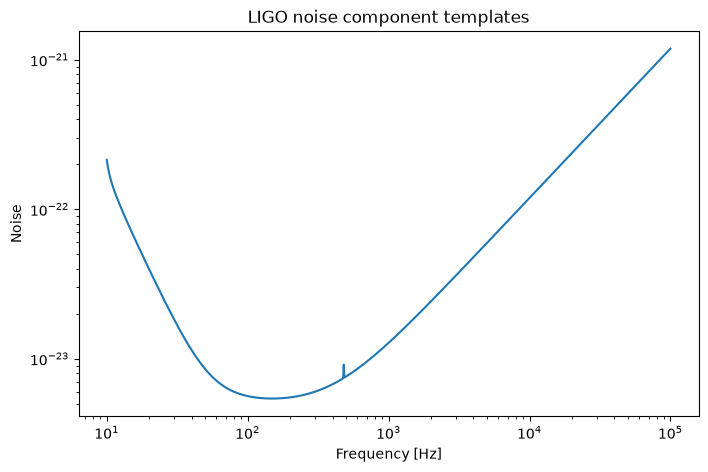

In [12]:
ligo_noise = gwr.LIGO_noise(freqs)

fig = plt.figure(figsize=(8, 5))
plt.loglog(freqs, ligo_noise, label="ligo noise")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Noise")
plt.title("LIGO noise component templates")

if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/ligo_psd.npy", np.array(ligo_noise))

## Module: `single_link`

Implementation of the various helper functions to compute the single link response

In [13]:
# Compute a unit vector in the direction of theta, phi
unit_vector = gwr.unit_vec(theta, phi)
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/unit_vector.npy", np.array(unit_vector))
print("unit_vector shape:", unit_vector.shape, "[xyz, pixel]")

unit_vector shape: (3, 768) [xyz, pixel]


In [14]:
# Complete an orthogonal basis for a given unit vector along theta, phi
u, v = gwr.uv_analytical(theta, phi)
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/u.npy", np.array(u))
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/v.npy", np.array(v))
print("u shape:", u.shape, "[pixel, xyz]")
print("v shape:", v.shape, "[pixel, xyz]")
# These can be used to compute polarization vectors
e1, e2 = gwr.polarization_vectors(u, v)
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/e1.npy", np.array(e1))
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/e2.npy", np.array(e2))
print("e1 shape:", e1.shape, "[pixel, xyz]")
print("e2 shape:", e2.shape, "[pixel, xyz]")
# Or polarisation tensors in some basis
e1p, e1c = gwr.polarization_tensors_PC(u, v)
e1L, e1R = gwr.polarization_tensors_LR(u, v)
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/e1p.npy", np.array(e1p))
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/e1c.npy", np.array(e1c))
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/e1L.npy", np.array(e1L))
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/e1R.npy", np.array(e1R))
print("e1p shape:", e1p.shape, "[pixel, xyz, xyz]")
print("e1c shape:", e1c.shape, "[pixel, xyz, xyz]")
print("e1L shape:", e1L.shape, "[pixel, xyz, xyz]")
print("e1R shape:", e1R.shape, "[pixel, xyz, xyz]")

u shape: (768, 3) [pixel, xyz]
v shape: (768, 3) [pixel, xyz]
e1 shape: (768, 3) [pixel, xyz]
e2 shape: (768, 3) [pixel, xyz]
e1p shape: (768, 3, 3) [pixel, xyz, xyz]
e1c shape: (768, 3, 3) [pixel, xyz, xyz]
e1L shape: (768, 3, 3) [pixel, xyz, xyz]
e1R shape: (768, 3, 3) [pixel, xyz, xyz]


In [15]:
# There are a set of functions to compute the various quantities in the response
xi_k = gwr.single_link_static.xi_k_no_G_static(
    unit_wavevector=unit_vector,
    x_vector=ligo.x(freqs),
    arms_matrix_rescaled=ligo.detector_arms(0.0) / ligo.armlength,
)
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/xi_k.npy", np.array(xi_k))
print("xi_k shape:", xi_k.shape, "[time, freq, arms, pixel]")

xi_k shape: (1, 1000, 4, 768) [time, freq, arms, pixel]


In [16]:
# Or the exponential of the position
position_exp = gwr.position_exponential(
    positions_detector_frame_rescaled=jnp.array([[sp1, sp2, sp3]]) / ligo.armlength,
    unit_wavevector=unit_vector,
    x_vector=ligo.x(freqs),
)
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/position_exp.npy", np.array(position_exp))
print("position_exp shape:", position_exp.shape, "[time, freq, arms, pixel]")

# Or a geometrical factor
geomtrical_factor = gwr.geometrical_factor(
    arms_matrix_rescaled=ligo.detector_arms(0.0) / ligo.armlength,
    polarization_tensor=e1L,
)
print("geometrical_factor shape:", geomtrical_factor.shape, "[time, arms, pixel]")
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/geometrical_factor.npy", np.array(geomtrical_factor))

# Or a different version of xi_k
xi_k_Avec = gwr.xi_k_A_static(
    arms_matrix_rescaled=ligo.detector_arms(0.0) / ligo.armlength,
    unit_wavevector=unit_vector,
    x_vector=ligo.x(freqs),
    geometrical=geomtrical_factor,
)
if GENERATE_TEST_DATA:
    np.save("../testing/test_data_ligo/xi_k_Avec.npy", np.array(xi_k_Avec))
print("xi_k_Avec shape:", xi_k_Avec.shape, "[time, freq, arms, pixel]")

position_exp shape: (1, 1000, 3, 768) [time, freq, arms, pixel]
geometrical_factor shape: (1, 4, 768) [time, arms, pixel]
xi_k_Avec shape: (1, 1000, 4, 768) [time, freq, arms, pixel]


## Module: `response`

Implements a `Response` class for computing the angular and integrated response in a given detector

In [17]:
# Set up the response object
response = ligo.response

In [18]:
# Angular response
single_link_response = response.get_single_link_response_fd(
    ligo,
    times_in_years=jnp.array([0.0]),
    theta_array=theta,
    phi_array=phi,
    frequency_array=freqs,
    polarization="LR",
)

if GENERATE_TEST_DATA:
    np.save(
        "../testing/test_data_ligo/single_link_response_L.npy",
        np.array(single_link_response["L"]),
    )
if GENERATE_TEST_DATA:
    np.save(
        "../testing/test_data_ligo/single_link_response_R.npy",
        np.array(single_link_response["R"]),
    )
print(
    "single_link_response shape:",
    single_link_response["L"].shape,
    "[time, freq, arms, pixel]",
)

single_link_response shape: (1, 1000, 4, 768) [time, freq, arms, pixel]


In [19]:
# Compute the full integrated response (still using the Michelson combination)

response.compute_detector(
    ligo,
    times_in_years=jnp.array([0.0]),
    theta_array=theta,
    phi_array=phi,
    frequency_array=freqs,
    polarization="LR",
)

print(
    "response shape:",
    response.quadratic_integrated["Michelson"]["L"].shape,
    "[time, freq, pixel]",
)
if GENERATE_TEST_DATA:
    np.save(
        "../testing/test_data_ligo/quadratic_response_L.npy",
        np.array(response.quadratic_integrated["Michelson"]["L"]),
    )
if GENERATE_TEST_DATA:
    np.save(
        "../testing/test_data_ligo/quadratic_response_R.npy",
        np.array(response.quadratic_integrated["Michelson"]["R"]),
    )

response shape: (1, 1000, 768) [time, freq, pixel]


Text(0.5, 1.0, 'Linear response')

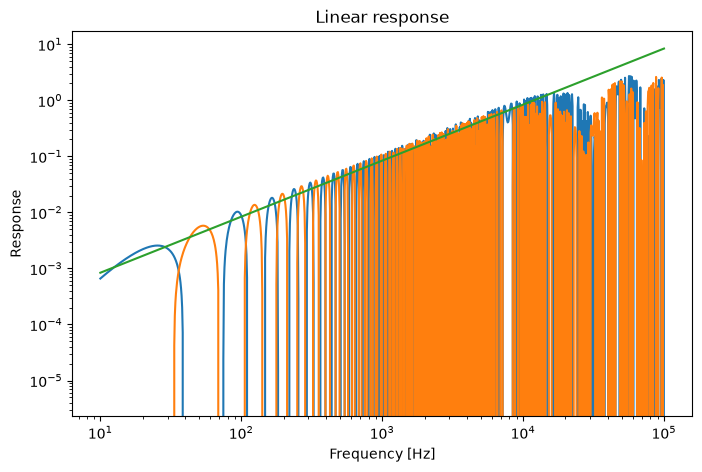

In [20]:
fig = plt.figure(figsize=(8, 5))
plt.loglog(freqs, response.linear_integrand["Michelson"]["R"][0, :, 0])
plt.loglog(freqs, response.linear_integrand["Michelson"]["L"][0, :, 0])
plt.loglog(freqs, ligo.x(freqs))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Response")
plt.title("Linear response")

In [21]:
# Recompute, this time saving the linear integrand (still using the Michelson combination)

response.compute_detector(
    ligo,
    times_in_years=jnp.array([0.0]),
    theta_array=theta,
    phi_array=phi,
    frequency_array=freqs,
    polarization="LR",
)
print(
    "response shape:",
    response.linear_integrand["Michelson"]["L"].shape,
    "[time, freq, pixel]",
)

if GENERATE_TEST_DATA:
    np.save(
        "../testing/test_data_ligo/linear_integrand_L.npy",
        np.array(response.linear_integrand["Michelson"]["L"]),
    )
if GENERATE_TEST_DATA:
    np.save(
        "../testing/test_data_ligo/linear_integrand_R.npy",
        np.array(response.linear_integrand["Michelson"]["R"]),
    )

response shape: (1, 1000, 768) [time, freq, pixel]


Text(0.5, 1.0, 'Linear response')

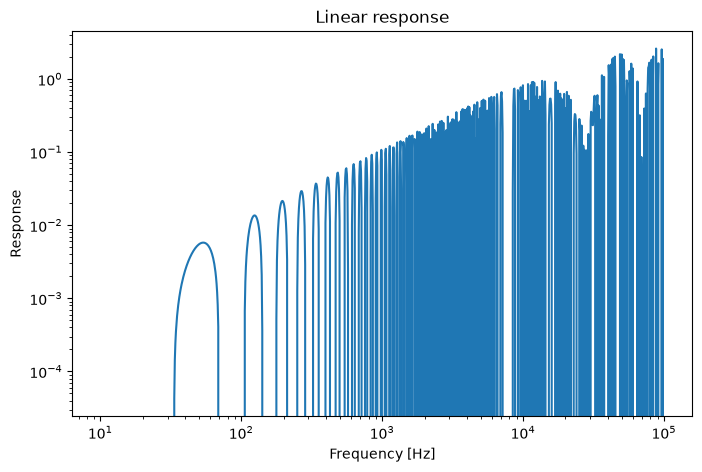

In [22]:
fig = plt.figure(figsize=(8, 5))
plt.loglog(freqs, response.linear_integrand["Michelson"]["L"][0, :, 0])
plt.xlabel("Frequency [Hz]")
plt.ylabel("Response")
plt.title("Linear response")

Text(0.5, 1.0, 'Integrand')

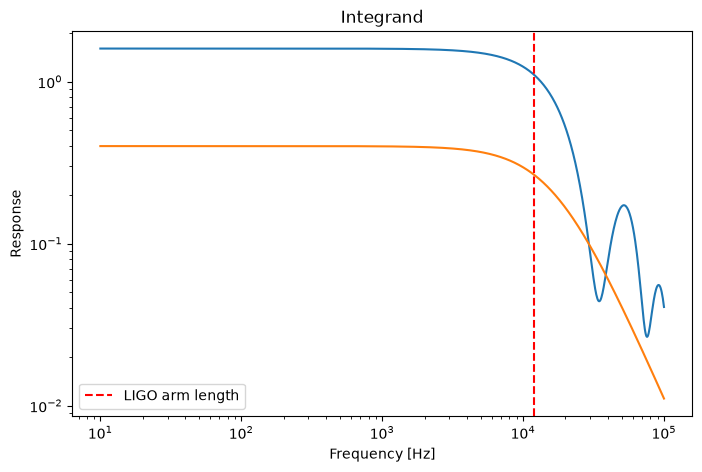

In [23]:
fig = plt.figure(figsize=(8, 5))
plt.loglog(freqs, np.mean(response.quadratic_integrand["Michelson"]["R"][0, :, :], axis=-1) / ligo.x(freqs) ** 2)
plt.axvline(3e8 / (2 * np.pi * 4e3), color="red", linestyle="--", label="LIGO arm length")
plt.loglog(freqs, 2 / 5 * 1 / (1 + 0.5 * ligo.x(freqs) ** 2))
plt.legend()
plt.xlabel("Frequency [Hz]")
plt.ylabel("Response")
plt.title("Integrand")